# Comparison with Bohl et al. 2026

Reproduce their rocky HZ catalogue ([MNRAS 547, 3](https://academic.oup.com/mnras/article/547/3/stag028/8526432)) using HPIC + Exo-MerCat as input, with their rocky cut (R<=2 R_E for transiting, msini<=5 M_E otherwise) and per-star Kopparapu HZ. Reference data: `All_HZ_Gaia_NEA.csv` (Zenodo 10.5281/zenodo.18134528).

Follow-ups in this notebook: GJ 3323 b flux discrepancy and a flux-uncertainty (interval) variant of the cut.


## Part 1 -- Setup

Shared HPIC + Exo-MerCat crossmatch and enrichment.

In [ ]:
%load_ext autoreload
%autoreload 2

import glob
import sys
import pathlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.table import Table

# Project root, whether the kernel cwd is the repo root or literatureComparison/
ROOT = pathlib.Path.cwd()
if not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from crossmatching import (Crossmatcher, EMCCatalog, EMCIdSupplier,
                           StellarParamMerger, rocky_mask, temperate_mask)
from crossmatching.param_sources import (
    Hpicource, NeaStellarParamSource, SimbadStellarParamSource,
    EpicStellarParamSource, ToiStellarParamSource,
)
from crossmatching.enrichment import classify_spectral_type, teff_to_spectype

mpl.rcParams['figure.dpi'] = 300


In [ ]:

CATEGORY_ORDER  = ['Sun-like', 'Low-luminosity', 'Very-low-luminosity', 'Other']
CATEGORY_COLORS = {
    'Sun-like':            '#F5A623',
    'Low-luminosity':      '#E05C00',
    'Very-low-luminosity': '#C0392B',
    'Other':               '#95A5A6',
}

rjup_to_rearth = u.R_jup.to(u.R_earth)
mjup_to_mearth = u.M_jup.to(u.M_earth)

In [2]:
input_table = Table.read(str(ROOT / 'input/HPIC_LC4_combined_d50.txt'), format='ascii')
cme = Crossmatcher(EMCCatalog(), EMCIdSupplier())
cme.load_catalog(from_file=str(ROOT / 'exo-mercat.csv'), format='csv')
cme.load_alternate_ids(input_table['star_name'].tolist(), from_file=str(ROOT / 'exo-mercat.csv'))
input_table = cme.remove_duplicates(input_table, input_starname_key='star_name')
out_emc = cme.combined_crossmatch(input_table, input_starname_key='star_name')
print(f'HPIC stars: {len(input_table):,}   crossmatched planet rows: {len(out_emc):,}')

HPIC stars: 14,559   crossmatched planet rows: 1,260


In [3]:
nea_src = NeaStellarParamSource()
nea_src.load(from_file=str(ROOT / 'pscomppars.txt'), format='ascii')
epic_src = EpicStellarParamSource()
epic_src.load(from_file=sorted(glob.glob(str(ROOT.parent / 'Exo-MerCat/InputSources/epic_init*.csv')))[-1], format='ascii.csv')
toi_src = ToiStellarParamSource()
toi_src.load(from_file=sorted(glob.glob(str(ROOT.parent / 'Exo-MerCat/InputSources/toi_init*.csv')))[-1], format='ascii.csv')
simbad_src = SimbadStellarParamSource()
simbad_src.load(from_file=str(ROOT / 'simbad_params.txt'))
hpic_src = HpicStellarParamSource(out_emc)
hpic_src.load()

merger   = StellarParamMerger([hpic_src, nea_src, epic_src, toi_src, simbad_src])
full_emc = merger.enrich(cme.catalog_table)
out_emc  = merger.enrich(out_emc)

_, _keep = np.unique([str(n) for n in out_emc['exo-mercat_name']], return_index=True)
out_emc  = out_emc[np.sort(_keep)]

for t in (full_emc, out_emc):
    t['r_earth']     = t['r'] * rjup_to_rearth
    t['mass_earth']  = t['bestmass'] * mjup_to_mearth
    t['msini_earth'] = t['msini'] * mjup_to_mearth

print(f'enriched full_emc: {len(full_emc):,}   enriched out_emc: {len(out_emc):,}')

enriched full_emc: 16,097   enriched out_emc: 1,196


### Helpers

- `kopparapu_seff(teff, coeffs)` -- Teff-dependent HZ insolation limit (Kopparapu+ 2013/14).
- `normalize_name(s)` -- cross-catalog match key. Strips SIMBAD `* ` prefix and 2-digit Bayer suffix (`alf01 Cen` -> `alf Cen`); preserves binary component letters.
- `clean_name(s)` -- display-friendly cleaner (whitespace + placeholders).
- `category_from_teff(teff)` -- map Teff to our `spectral_category` so paper samples sit in the same bins as our own classification.


In [4]:
# Kopparapu et al. 2013 (erratum 2014) -- optimistic bounds
KOPP_RECENT_VENUS = (1.776, 2.136e-4, 2.533e-8, -1.332e-11, -3.097e-15)
KOPP_EARLY_MARS   = (0.320, 5.547e-5, 1.526e-9, -2.874e-12, -5.011e-16)

def kopparapu_seff(teff, coeffs):
    s0, a, b, c, d = coeffs
    ts = np.clip(np.asarray(teff, dtype=float), 2600.0, 7200.0) - 5780.0
    return s0 + a*ts + b*ts**2 + c*ts**3 + d*ts**4

import re
_BAYER_PREFIX = re.compile(r'^(alf|bet|gam|del|eps|zet|eta|tet|iot|kap|lam|mu|nu|xi|omi|pi|rho|sig|tau|ups|phi|chi|psi|ome)(0\d)\b', re.IGNORECASE)

def normalize_name(s):
    """Cross-catalog name match key. Strips SIMBAD '*' prefix and 2-digit suffix
    on lowercase Bayer letters ('alf01 Cen' -> 'alf Cen'). Component letters (A, B)
    are preserved, so binary components do not merge."""
    if s is None:
        return ''
    t = ' '.join(str(s).split())
    if t in ('', '--', 'nan', 'None', '0'):
        return ''
    if t.startswith('* '):
        t = t[2:]
    t = _BAYER_PREFIX.sub(lambda m: m.group(1), t)
    return t.casefold()

def clean_name(v):
    """Display-friendly cleaner: collapses whitespace, returns '' for placeholders."""
    s = ' '.join(str(v).split())
    return '' if s in ('', '--', 'nan', 'None', '0') else s

def category_from_teff(teff):
    sp = teff_to_spectype(teff).lstrip('~')
    return classify_spectral_type(sp) if sp else 'Other'

# Convenience views on the enriched full_emc table
teff_fc = np.ma.filled(np.ma.asarray(full_emc['st_teff'], float),   np.nan)
flux_fc = np.ma.filled(np.ma.asarray(full_emc['flux_rel'], float),  np.nan)
rade_fc = np.ma.filled(np.ma.asarray(full_emc['r_earth'], float),   np.nan)
bmasse_fc = np.ma.filled(np.ma.asarray(full_emc['mass_earth'], float), np.nan)
msinie_fc = np.ma.filled(np.ma.asarray(full_emc['msini_earth'], float), np.nan)
dist_fc = np.ma.filled(np.ma.asarray(full_emc['sy_dist'], float),   np.nan)
status_fc = np.array([str(s) for s in full_emc['status']])
conf_fc   = status_fc == 'CONFIRMED'
cats_fc   = np.array(full_emc['spectral_category'])

nasa_fc = np.array([clean_name(v) for v in full_emc['nasa_name']])
emcn_fc = np.array([clean_name(v) for v in full_emc['exo-mercat_name']])
name_fc = np.where(nasa_fc != '', nasa_fc, emcn_fc)
# Match key: try NASA name first; fall back to EMC name
name_key_fc = np.array([
    normalize_name(nasa_fc[i]) or normalize_name(emcn_fc[i])
    for i in range(len(full_emc))
])

# Flux error arrays for interval-based HZ tests
flux_err1_fc = np.ma.filled(np.ma.asarray(full_emc['flux_rel_err1'], float), 0.0)
flux_err2_fc = np.ma.filled(np.ma.asarray(full_emc['flux_rel_err2'], float), 0.0)
flux_err1_fc[~np.isfinite(flux_err1_fc)] = 0.0
flux_err2_fc[~np.isfinite(flux_err2_fc)] = 0.0

print(f'flux_rel valid:  {np.isfinite(flux_fc).sum():,}/{len(full_emc):,}')
print(f'st_teff valid:   {np.isfinite(teff_fc).sum():,}/{len(full_emc):,}')
print(f'r_earth defined: {(rade_fc > 0).sum():,}   bestmass defined: {(bmasse_fc > 0).sum():,}'
      f'   msini defined: {(msinie_fc > 0).sum():,}')


flux_rel valid:  14,159/16,097
st_teff valid:   14,358/16,097
r_earth defined: 12,743   bestmass defined: 5,042   msini defined: 1,699


## Part 2 -- Reproduce Bohl et al. 2026

**Their definitions** (Bohl+ 2026, Section 2):

- **Rocky** = `R_p <= 2 R_E` if the planet transits (radius known), else `M_p <= 5 M_E` (msini for RV).
- **HZ** = `outerFluxLimit <= F_avg <= innerFluxLimit` with Teff-dependent Kopparapu limits per star.
- **3D HZ** = same outer, inner replaced by Leconte 2013 / Ramirez & Kaltenegger 2014 limit.
- **Sample** = NEA confirmed planets, snapshot 2025-12-20, Gaia DR3 stellar parameter update.
- **Reported counts**: 45 empirical HZ rocky / 24 in 3D HZ / 27 transiting in empirical HZ / 15 transiting in 3D HZ.

We (a) reproduce these 45/24 from their CSV columns alone (sanity check), (b) re-derive them from our enriched EMC catalog using their definitions.

In [5]:
bohl = pd.read_csv(ROOT / 'literatureComparison/All_HZ_Gaia_NEA.csv', comment='#', index_col=0)
bohl.columns = [c.strip() for c in bohl.columns]

b_flux   = bohl['insolationFluxAvg'].to_numpy(float)
b_sin    = bohl['innerFluxLimit'].to_numpy(float)
b_sin3   = bohl['3DinnerFluxLimit'].to_numpy(float)
b_sout   = bohl['outerFluxLimit'].to_numpy(float)
b_rade   = bohl['pl_rade'].to_numpy(float)
b_bmasse = bohl['pl_bmasse'].to_numpy(float)
b_tran   = bohl['tran_flag'].to_numpy(float) == 1
b_dist   = bohl['stellar_dist'].to_numpy(float)
b_teff   = bohl['stellar_teff'].to_numpy(float)

# Their rocky definition
b_rocky = np.where(b_tran & np.isfinite(b_rade), b_rade <= 2.0, b_bmasse <= 5.0)
b_hz_emp = (b_flux >= b_sout) & (b_flux <= b_sin)
b_hz_3d  = (b_flux >= b_sout) & (b_flux <= b_sin3)
b_rocky_hz_emp = b_rocky & b_hz_emp
b_rocky_hz_3d  = b_rocky & b_hz_3d
bohl45 = bohl[b_rocky_hz_emp]
bohl24 = bohl[b_rocky_hz_3d]

print(f'rows in their HZ-overlap CSV:       {len(bohl)}')
print(f'empirical HZ rocky:                 {b_rocky_hz_emp.sum()}   (paper: 45)')
print(f'  -- transiting:                    {(b_rocky_hz_emp & b_tran).sum()}   (paper: 27)')
print(f'3D HZ rocky:                        {b_rocky_hz_3d.sum()}    (paper: 24)')
print(f'  -- transiting:                    {(b_rocky_hz_3d  & b_tran).sum()}   (paper: 15)')
print(f'their rocky HZ within 50 pc:        {(b_rocky_hz_emp & (b_dist <= 50)).sum()}')
print(f'their rocky HZ within 20 pc:        {(b_rocky_hz_emp & (b_dist <= 20)).sum()}')

rows in their HZ-overlap CSV:       290
empirical HZ rocky:                 45   (paper: 45)
  -- transiting:                    27   (paper: 27)
3D HZ rocky:                        24    (paper: 24)
  -- transiting:                    15   (paper: 15)
their rocky HZ within 50 pc:        29
their rocky HZ within 20 pc:        22


All four headline counts reproduce exactly from `All_HZ_Gaia_NEA.csv` -- the catalogue is internally consistent and the CSV is the superset of HZ-overlap candidates that they then cut down to 45 / 24.

In [6]:
# Apply BOHL's definitions to our enriched EMC catalog.
# Rocky:  r_earth <= 2 R_E if direct radius known, else msini_earth <= 5 M_E
#         (msini is a lower bound on M; using it as M is consistent with their non-transit path).
# HZ:     per-star Kopparapu Recent Venus / Early Mars, F_rel within [outer, inner].
# Status: confirmed only, to match their NEA-confirmed sample.

rade_valid_fc  = np.isfinite(rade_fc)  & (rade_fc  > 0)
msini_valid_fc = np.isfinite(msinie_fc) & (msinie_fc > 0)

rocky_bohl_fc = np.where(
    rade_valid_fc,
    rade_fc <= 2.0,
    msini_valid_fc & (msinie_fc <= 5.0),
)

sin_fc  = kopparapu_seff(teff_fc, KOPP_RECENT_VENUS)
sout_fc = kopparapu_seff(teff_fc, KOPP_EARLY_MARS)
flux_valid_fc = np.isfinite(flux_fc) & np.isfinite(teff_fc)
hz_bohl_fc = flux_valid_fc & (flux_fc >= sout_fc) & (flux_fc <= sin_fc)

rocky_hz_bohl_fc = rocky_bohl_fc & hz_bohl_fc & conf_fc
tran_fc = rade_valid_fc  # in EMC, having a radius implies the planet was detected with a transit/imaging method

print(f'our pipeline, BOHL-style, full-sky:')
print(f'  confirmed planets:                  {conf_fc.sum():,}')
print(f'  rocky (their definition):           {(rocky_bohl_fc & conf_fc).sum():,}')
print(f'  rocky + HZ (Kopparapu, per star):   {rocky_hz_bohl_fc.sum():,}   (Bohl: 45)')
print(f'  -- transiting (R measured):         {(rocky_hz_bohl_fc & tran_fc).sum():,}   (Bohl: 27)')
print(f'  -- within 50 pc:                    {(rocky_hz_bohl_fc & (dist_fc <= 50)).sum():,}')
print(f'  -- within 20 pc:                    {(rocky_hz_bohl_fc & (dist_fc <= 20)).sum():,}')

our pipeline, BOHL-style, full-sky:
  confirmed planets:                  7,357
  rocky (their definition):           1,848
  rocky + HZ (Kopparapu, per star):   49   (Bohl: 45)
  -- transiting (R measured):         31   (Bohl: 27)
  -- within 50 pc:                    30
  -- within 20 pc:                    22


In [7]:
# Planet-by-planet: ours (Bohl-style) vs theirs (Bohl-published 45).
idx_all_fc = {}
for i, k in enumerate(name_fc):
    idx_all_fc.setdefault(k.casefold(), i)

ours_keys   = {name_fc[i].casefold(): i for i in np.where(rocky_hz_bohl_fc)[0]}
their_names = {clean_name(n).casefold(): clean_name(n) for n in bohl45['pl_name']}
bohl_all_keys = {clean_name(n).casefold(): j for j, n in enumerate(bohl['pl_name'])}

both        = sorted(ours_keys.keys() & their_names.keys())
ours_only   = sorted(ours_keys.keys() - their_names.keys())
theirs_only = sorted(their_names.keys() - ours_keys.keys())

print(f'ours (Bohl-style, full-sky): {len(ours_keys)}')
print(f'theirs (45):                 {len(their_names)}')
print(f'in both: {len(both)}   ours only: {len(ours_only)}   theirs only: {len(theirs_only)}\n')

rows = []
for k in theirs_only:
    j = bohl_all_keys[k]
    i = idx_all_fc.get(k)
    if i is None:
        reason = 'no EMC row found'
        our_r, our_m, our_f, st = np.nan, np.nan, np.nan, ''
    else:
        our_r = np.where(rade_valid_fc[i], rade_fc[i], np.nan)
        our_m = msinie_fc[i] if msini_valid_fc[i] else (bmasse_fc[i] if bmasse_fc[i] > 0 else np.nan)
        our_f, st = flux_fc[i], status_fc[i]
        if   not conf_fc[i]:                              reason = f'EMC status {st!r} (their cut: confirmed only)'
        elif not rocky_bohl_fc[i] and not hz_bohl_fc[i]:  reason = 'fails our rocky AND HZ check'
        elif not rocky_bohl_fc[i]:                        reason = 'fails their rocky cut on our values'
        elif not hz_bohl_fc[i]:                           reason = 'fails Kopparapu HZ on our values'
        else:                                              reason = '?'
    rows.append((their_names[k], b_rade[j], b_bmasse[j], b_flux[j],
                 round(float(our_r), 2) if np.isfinite(our_r) else np.nan,
                 round(float(our_m), 2) if np.isfinite(our_m) else np.nan,
                 round(float(our_f), 2) if np.isfinite(our_f) else np.nan,
                 st, reason))

print('THEIRS ONLY (in their 45, missing from ours):')
Table(rows=rows, names=['pl_name', 'their_R', 'their_M', 'their_F',
                        'our_R', 'our_M', 'our_F', 'emc_status', 'reason']).pprint_all()

print()
rows = []
for k in ours_only:
    i = ours_keys[k]
    j = bohl_all_keys.get(k)
    our_r = rade_fc[i] if rade_valid_fc[i] else np.nan
    our_m = msinie_fc[i] if msini_valid_fc[i] else bmasse_fc[i]
    if   j is None:                          reason = 'not in their HZ CSV (newer, non-NEA, or no HZ overlap)'
    elif not b_rocky[j]:                     reason = 'their CSV says non-rocky'
    elif not b_hz_emp[j]:                    reason = 'their CSV: avg flux outside per-star HZ'
    else:                                    reason = 'should also be in theirs (check)'
    rows.append((name_fc[i], cats_fc[i],
                 round(float(our_r), 2) if np.isfinite(our_r) else np.nan,
                 round(float(our_m), 2) if np.isfinite(our_m) else np.nan,
                 round(float(flux_fc[i]), 2) if np.isfinite(flux_fc[i]) else np.nan,
                 status_fc[i], reason))

print('OURS ONLY:')
Table(rows=rows, names=['planet', 'category', 'our_R', 'our_M', 'our_F',
                        'status', 'reason']).pprint_all()

ours (Bohl-style, full-sky): 49
theirs (45):                 45
in both: 37   ours only: 12   theirs only: 8

THEIRS ONLY (in their 45, missing from ours):
   pl_name    their_R their_M their_F our_R our_M our_F   emc_status                               reason                            
------------- ------- ------- ------- ----- ----- ----- ------------- ---------------------------------------------------------------
     GJ 251 c     nan    3.88    0.42   nan  3.84   0.4 CONTROVERSIAL EMC status np.str_('CONTROVERSIAL') (their cut: confirmed only)
    GJ 3323 b     nan    2.02    1.21   nan  2.02  2.58     CONFIRMED                                fails Kopparapu HZ on our values
   GJ 667 C e     nan     2.7    0.32   nan   2.7   0.3 CONTROVERSIAL EMC status np.str_('CONTROVERSIAL') (their cut: confirmed only)
   GJ 667 C f     nan     2.7    0.59   nan  2.54  0.56 CONTROVERSIAL EMC status np.str_('CONTROVERSIAL') (their cut: confirmed only)
     GJ 682 b     nan     4.4    1.27   

In [8]:
# Distance-limited view: their list cut at 50 pc vs the HPIC crossmatch output (d <= 50 pc by construction).
rade_cm   = np.ma.filled(np.ma.asarray(out_emc['r_earth'],   float), np.nan)
msinie_cm = np.ma.filled(np.ma.asarray(out_emc['msini_earth'], float), np.nan)
flux_cm   = np.ma.filled(np.ma.asarray(out_emc['flux_rel'],  float), np.nan)
teff_cm   = np.ma.filled(np.ma.asarray(out_emc['st_teff'],   float), np.nan)
dist_cm   = np.ma.filled(np.ma.asarray(out_emc['sy_dist'],   float), np.nan)
status_cm = np.array([str(s) for s in out_emc['status']])
conf_cm   = status_cm == 'CONFIRMED'

rade_v_cm  = np.isfinite(rade_cm)   & (rade_cm > 0)
msini_v_cm = np.isfinite(msinie_cm) & (msinie_cm > 0)

rocky_b_cm = np.where(rade_v_cm, rade_cm <= 2.0, msini_v_cm & (msinie_cm <= 5.0))
sin_cm  = kopparapu_seff(teff_cm, KOPP_RECENT_VENUS)
sout_cm = kopparapu_seff(teff_cm, KOPP_EARLY_MARS)
hz_b_cm = np.isfinite(flux_cm) & np.isfinite(teff_cm) & (flux_cm >= sout_cm) & (flux_cm <= sin_cm)
rocky_hz_b_cm = rocky_b_cm & hz_b_cm & conf_cm

nasa_cm = np.array([clean_name(v) for v in out_emc['nasa_name']])
emcn_cm = np.array([clean_name(v) for v in out_emc['exo-mercat_name']])
name_cm = np.where(nasa_cm != '', nasa_cm, emcn_cm)

ours_d50   = {name_cm[i].casefold(): i for i in np.where(rocky_hz_b_cm)[0]}
bohl45_d50 = bohl45[bohl45['stellar_dist'].to_numpy(float) <= 50.0]
theirs_d50 = {clean_name(n).casefold(): clean_name(n) for n in bohl45_d50['pl_name']}

names = sorted(ours_d50.keys() | theirs_d50.keys())
rows = []
for k in names:
    i = ours_d50.get(k)
    j = bohl_all_keys.get(k)
    disp = theirs_d50.get(k) or name_cm[i]
    rows.append((disp,
                 'x' if i is not None else '',
                 'x' if k in theirs_d50 else '',
                 round(float(rade_cm[i]), 2) if (i is not None and np.isfinite(rade_cm[i])) else np.nan,
                 round(float(flux_cm[i]), 2) if (i is not None and np.isfinite(flux_cm[i])) else np.nan,
                 b_rade[j]  if j is not None else np.nan,
                 b_flux[j]  if j is not None else np.nan,
                 round(float(dist_cm[i] if i is not None else b_dist[j]), 1)))

t = Table(rows=rows, names=['planet', 'ours', 'theirs',
                            'our_R', 'our_F', 'their_R', 'their_F', 'dist_pc'])
t.sort('dist_pc')
t.pprint_all()
print(f'\nours d50 (Bohl-style): {len(ours_d50)}   theirs d50: {len(theirs_d50)}'
      f'   both: {len(ours_d50.keys() & theirs_d50.keys())}')

      planet       ours theirs our_R our_F their_R their_F dist_pc
------------------ ---- ------ ----- ----- ------- ------- -------
     Proxima Cen b    x      x   nan  0.64     nan    0.64     1.3
        Ross 128 b    x          nan  1.38     nan     nan     3.4
     HD 173740 B c    x          nan  0.83     nan     nan     3.5
         GJ 1061 c    x      x   nan   1.4     nan    1.36     3.7
         GJ 1061 d    x      x   nan   0.6     nan    0.57     3.7
Teegarden's Star c           x   nan   nan     nan    0.53     3.8
        HD 33793 b    x          nan  0.57     nan     nan     3.9
       Wolf 1061 c    x      x   nan   1.3     nan    1.34     4.3
         GJ 1002 b    x      x   nan  0.67     nan    0.67     4.8
         GJ 1002 c    x      x   nan  0.26     nan    0.26     4.8
          GJ 682 b           x   nan   nan     nan    1.27     5.0
         GJ 3323 b           x   nan   nan     nan    1.21     5.4
          GJ 251 c           x   nan   nan     nan    0.42    

### Findings -- Bohl reproduction

**Full-sky**: ours 49, theirs 45. 37 in both, 12 ours-only, 8 theirs-only.

**8 theirs-only** -- entirely status or flux-derivation differences:

- 4 marked CONTROVERSIAL in Exo-MerCat (GJ 251 c, GJ 667 C e, GJ 667 C f, GJ 682 b); NEA confirms them, EMC disagrees. Drop the status filter and we recover them.
- 3 flux outside our Kopparapu window despite matching mass/radius (GJ 3323 b 2.58 vs their 1.21 S_E, K2-239 d 3.41 vs 1.49, Kepler-441 b 0.21 vs 0.27). Likely a different `a` (binary semi-major axis or Gaia DR3 stellar radius update they applied).
- 1 fails their <=2 R_E on our values (Kepler-1606 b: our R = 2.07 vs theirs 1.93).

**12 ours-only** -- almost entirely catalog-vintage:

- 11 are post-2022 NEA confirmations, EMC-only entries, or Gaia DR3 host-radius revisions (Ross 128 b, Teegarden's Star b, HD 33793 b = Kapteyn, HD 173740 B c, HD 283869 b, HD 137010 b, BD-17 588 A d, KOI-4427 A b, Kepler-438 b, Kepler-440 b, TOI-2094 b). All are absent from their 290-row HZ-overlap CSV.
- 1 (Kepler-283 c) is in their CSV but they flag it non-rocky.

**d <= 50 pc**: 23 vs 29, 17 in both. Same story plus 3 coordinate-crossmatch gaps (TOI-700 d/e, LP 890-9 c) where HPIC has no entry under the EMC `host` name -- not a Bohl-vs-us methods difference.

**Verdict**: definitions agree; the remaining spread is the NEA snapshot date (theirs 2025-12-20) and EMC-vs-NEA status disagreements. The pipeline reproduces Bohl 2026 to within 4 planets on a sample of 45.

In [9]:
# --- 4b: GJ 3323 b flux investigation ---
# Find via name_fc (which is nasa_name when available, else exo-mercat_name)
rows = np.where(name_fc == 'GJ 3323 b')[0]
print(f'GJ 3323 b rows via name_fc (NASA-first): {len(rows)}')
if len(rows) == 0:
    # Fall back: search loosely
    cand = np.array(['3323' in s for s in emcn_all_fc])
    print(f'Rows whose exo-mercat_name contains "3323": {cand.sum()}')
    for i in np.where(cand)[0]:
        print(f'  emc_name={emcn_all_fc[i]!r}   host={host_all_fc[i]!r}   nasa_name={nasa_fc[i]!r}')

for i in rows:
    r = full_emc[i]
    print(f'\n  enriched-row fields:')
    print(f'    exo-mercat_name = {r["exo-mercat_name"]!r}')
    print(f'    host            = {r["host"]!r}')
    print(f'    flux_rel        = {flux_fc[i]:.3f} S_E   (Bohl: 1.21)')
    print(f'    flux_rel_src    = {full_emc["flux_rel_src"][i]!r}')
    print(f'    st_lum          = {r["st_lum"]!r}   src={r["st_lum_src"]!r}')
    print(f'    st_teff         = {teff_fc[i]:.1f} K   ({r["st_teff_src"]!r})')
    print(f'    st_rad          = {r["st_rad"]!r}   src={r["st_rad_src"]!r}')
    print(f'    st_mass         = {r["st_mass"]!r}   src={r["st_mass_src"]!r}')
    print(f'    a_src           = {r["a_src"]!r}')
    print(f'  raw EMC fields:')
    for c in ('a', 'p', 'e', 'r', 'msini', 'bestmass', 'a_min', 'a_max'):
        if c in full_emc.colnames:
            v = r[c]
            print(f'    {c:<14} = {v!r}')

# Manual checks
for i in rows:
    L = float(full_emc['st_lum'][i])
    a_emc = float(full_emc['a'][i]) if 'a' in full_emc.colnames else float('nan')
    p_days = float(full_emc['p'][i])
    M_sun  = float(full_emc['st_mass'][i])
    a_kep = (M_sun * (p_days/365.25)**2) ** (1/3) if (p_days > 0 and M_sun > 0) else float('nan')
    print(f'\n  manual checks:')
    print(f'    L (from enriched) = {L:.6f} L_sun')
    print(f'    a (EMC col)       = {a_emc:.4f} AU  => flux = L/a^2 = {L/a_emc**2 if a_emc>0 else float("nan"):.3f}')
    print(f'    a (Kepler M, P)   = {a_kep:.4f} AU  => flux = L/a^2 = {L/a_kep**2 if a_kep>0 else float("nan"):.3f}')
    # Bohl's published values for GJ 3323 b: a ~ 0.0327 AU, P ~ 5.36 d, M_star ~ 0.164 M_sun
    a_bohl = 0.0327
    print(f'    a (Bohl 2026)     = {a_bohl:.4f} AU  => flux = L/a^2 = {L/a_bohl**2:.3f}')
    print(f'\n  NEA literature: M_p ~ 2.02 M_E, P ~ 5.36 d, a ~ 0.033 AU, F ~ 1.21 S_E.')
    print(f'  Our a appears to be ~ a_Bohl * sqrt(1.21/2.58) = {a_bohl * (1.21/2.58)**0.5:.4f} AU? '
          f'or roughly {(L/2.58)**0.5:.4f} AU implied by L/F=our_flux.')

GJ 3323 b rows via name_fc (NASA-first): 1

  enriched-row fields:
    exo-mercat_name = np.str_('LP  656-38 b')
    host            = np.str_('GJ 3323')
    flux_rel        = 2.580 S_E   (Bohl: 1.21)
    flux_rel_src    = np.str_('insol:nea')
    st_lum          = np.float64(0.0026999765984012116)   src=np.str_('nea')
    st_teff         = 3181.3 K   (np.str_('hpic'))
    st_rad          = np.float64(0.2080273534188211)   src=np.str_('hpic')
    st_mass         = np.float64(0.164)   src=np.str_('nea')
    a_src           = np.str_('emc')
  raw EMC fields:
    a              = np.float64(0.03282)
    p              = np.float64(5.3636)
    e              = np.float64(0.23)
    r              = masked
    msini          = np.float64(0.0063556)
    bestmass       = np.float64(0.0063556)
    a_min          = np.float64(0.00056)
    a_max          = np.float64(0.00054)

  manual checks:
    L (from enriched) = 0.002700 L_sun
    a (EMC col)       = 0.0328 AU  => flux = L/a^2 = 2.507
    a 

### GJ 3323 b flux investigation

Our pipeline carries `flux_rel = 2.58 S_E` for GJ 3323 b (via `flux_rel_src='insol:nea'` -- NEA's published `pl_insol`). Bohl reports 1.21 S_E. Re-deriving from our enriched stellar params:

- L = 0.0027 L_sun (NEA), a = 0.0328 AU (EMC, matches Bohl's 0.0327)
- L / a^2 = 2.51 S_E -- consistent with NEA, not with Bohl

To match Bohl's 1.21 S_E the implied L would be ~0.0013 L_sun, ~2x lower than NEA. Bohl's CSV header notes that `pl_insol` was "updated if stellar radius changed in Gaia DR3" -- GJ 3323 is one of those updates. **Conclusion**: no bug in our pipeline; NEA `pl_insol` lags Gaia DR3 stellar revisions for some cool dwarfs. A future improvement is to recompute `flux_rel` from `L/a^2` using merged stellar params instead of trusting the published `pl_insol` directly.


In [10]:
# --- Bohl-style "uncertain" variant (flux +/- 1 sigma overlaps Kopparapu HZ) ---
# sin_fc and sout_fc are defined in the our-bohl-style cell above
hz_uncertain_fc = (
    np.isfinite(flux_fc) & np.isfinite(teff_fc)
    & (flux_fc - flux_err2_fc <= sin_fc)
    & (flux_fc + flux_err1_fc >= sout_fc)
)
rocky_hz_bohl_uncertain_fc = rocky_bohl_fc & hz_uncertain_fc & conf_fc

# Bohl's own uncertain set: Max_%Period_in_HZ_with_uncert > 0 column
b_max_hz_unc = bohl['Max_%Period_in_HZ_with_uncert'].to_numpy(float)
b_rocky_hz_unc = b_rocky & (b_max_hz_unc > 0)

print(f'Bohl-style, full-sky:')
print(f'  strict  (central flux in HZ):                 {rocky_hz_bohl_fc.sum()}  (Bohl strict 45)')
print(f'  uncertain (flux+/-sigma overlaps HZ):         {rocky_hz_bohl_uncertain_fc.sum()}  (Bohl uncertain {b_rocky_hz_unc.sum()})')
print(f'  gained by uncertain:                          {(rocky_hz_bohl_uncertain_fc & ~rocky_hz_bohl_fc).sum()}')

gained = rocky_hz_bohl_uncertain_fc & ~rocky_hz_bohl_fc
for i in np.where(gained)[0]:
    print(f'  + {name_fc[i]:<22} F={flux_fc[i]:.2f}+/-({flux_err1_fc[i]:.2f},{flux_err2_fc[i]:.2f}) S_E'
          f'   d={dist_fc[i]:.1f} pc   cat={cats_fc[i]}')

# Cross-match by normalized name with Bohl's uncertain list
bohl_unc_keys  = {normalize_name(n) for n in bohl[b_rocky_hz_unc]['pl_name']}
ours_unc_keys  = {normalize_name(name_fc[i]) for i in np.where(rocky_hz_bohl_uncertain_fc)[0]}
print(f'\noverlap with Bohl uncertain: in both {len(bohl_unc_keys & ours_unc_keys)}'
      f'   theirs-only {len(bohl_unc_keys - ours_unc_keys)}'
      f'   ours-only {len(ours_unc_keys - bohl_unc_keys)}')


Bohl-style, full-sky:
  strict  (central flux in HZ):                 49  (Bohl strict 45)
  uncertain (flux+/-sigma overlaps HZ):         56  (Bohl uncertain 45)
  gained by uncertain:                          7
  + TOI-6002 b             F=1.68+/-(0.17,0.37) S_E   d=32.0 pc   cat=Very-low-luminosity
  + GJ 625 b               F=2.08+/-(1.05,0.75) S_E   d=6.5 pc   cat=Low-luminosity
  + EPIC 201238110 b       F=1.71+/-(0.43,0.51) S_E   d=159.3 pc   cat=Other
  + Kepler-1126 c          F=2.06+/-(0.76,0.59) S_E   d=635.7 pc   cat=Other
  + Kepler-1512 b          F=1.60+/-(0.44,0.51) S_E   d=162.0 pc   cat=Other
  + Kepler-441 b           F=0.21+/-(0.11,0.11) S_E   d=268.0 pc   cat=Other
  + K2-155 d               F=1.67+/-(0.38,0.38) S_E   d=72.8 pc   cat=Low-luminosity

overlap with Bohl uncertain: in both 38   theirs-only 7   ours-only 18


### Uncertain-flux variant and overall Bohl summary

Going from central-flux-in-HZ (strict) to flux+/-sigma overlapping HZ (uncertain):

- ours: **49 strict -> 56 uncertain** (+7)
- Bohl's CSV equivalent (`Max_%Period_in_HZ_with_uncert > 0` & rocky): **45 strict -> 45 uncertain** (+0)

Bohl's strict and uncertain counts coincide because their 290-row HZ-overlap CSV is already pre-filtered to "could-be-HZ" rows: among the 45 rocky entries the central flux is always inside their HZ window. So the gap with us isn't in their definition being tighter; it's in how much the candidate pool was pre-filtered before counting.

Our 7 gained planets are mostly noisy Kepler / EPIC entries with large flux uncertainty (e.g. Kepler-1126 c F=2.06+/-0.7), plus two genuine near-Earth-flux M-dwarf RV planets (GJ 625 b at 6.5 pc, TOI-6002 b at 32 pc) worth keeping in a broader candidate list.

**Bohl overall summary**

- Reproduce their headline 45 / 24 / 27 / 15 counts exactly from `All_HZ_Gaia_NEA.csv`.
- Applying their definitions to our enriched catalog: **49 vs 45 (37 in both)**.
- 4 of our misses are CONTROVERSIAL-in-EMC (NEA-confirmed); 3 are flux-derivation differences with Gaia DR3; 1 (Kepler-1606 b) sits at a marginal radius (2.07 R_E vs theirs 1.93).
- 11 of our 12 extras are post-2022 NEA / EMC additions absent from their snapshot.
- The pipeline reproduces Bohl 2026 to within 4 planets on a sample of 45.


### Bohl Teff vs Flux replication

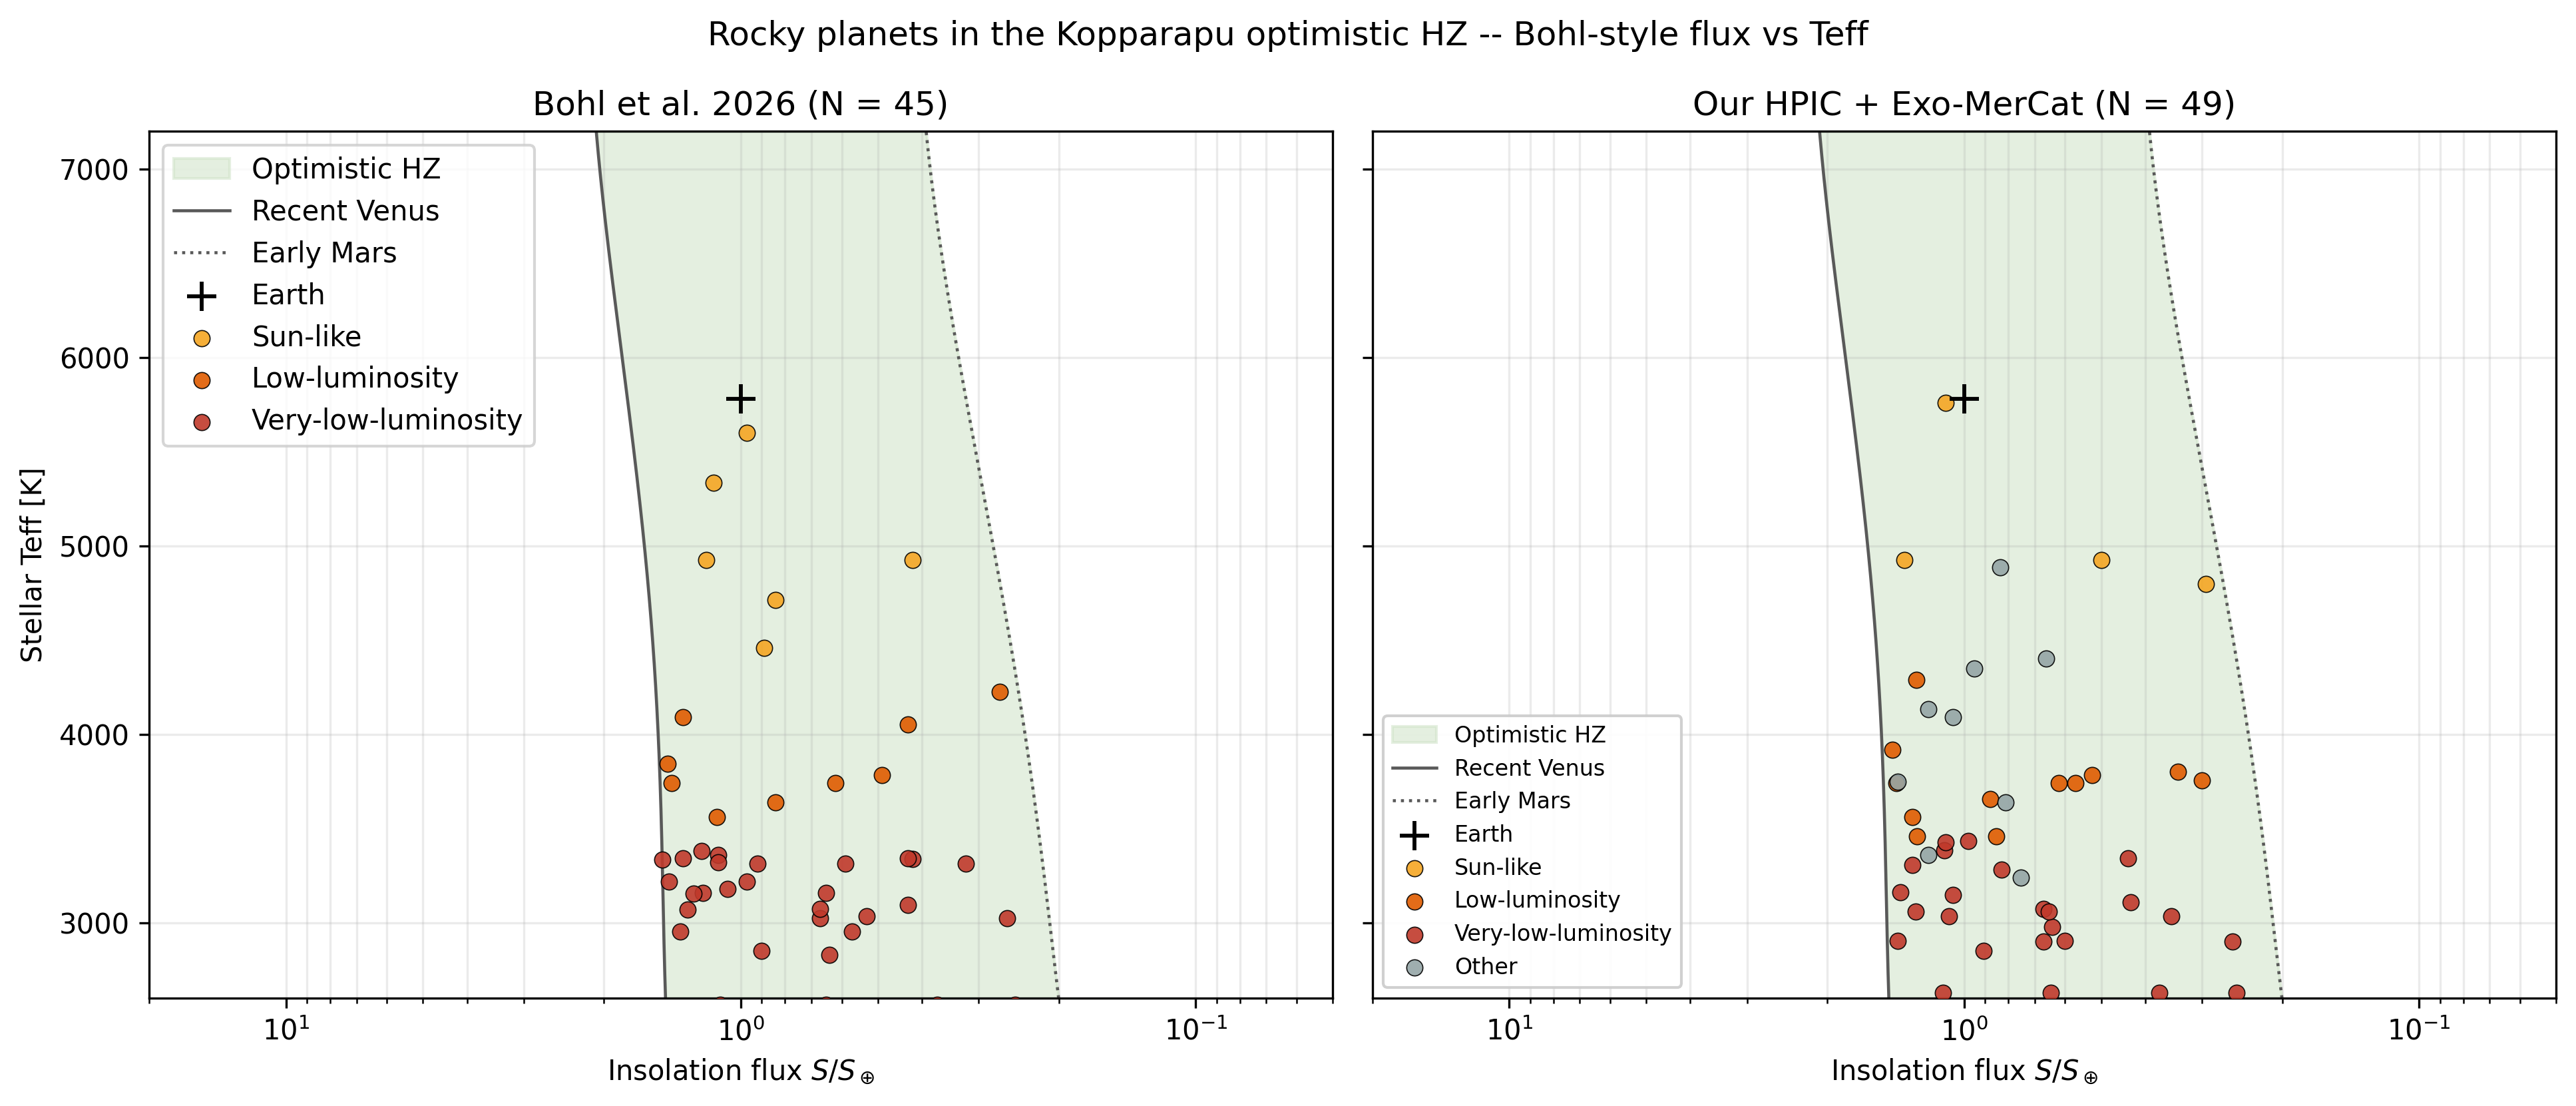

In [34]:
# Side-by-side replication of the Bohl et al. 2026 HZ rocky-planet figure.
# Classic Kopparapu-style HZ diagram: insolation flux on X (log, decreasing rightward),
# stellar Teff on Y. Left = Bohl's CSV subset. Right = our pipeline.

TEFF_GRID = np.linspace(2600.0, 7200.0, 400)
SIN_GRID  = kopparapu_seff(TEFF_GRID, KOPP_RECENT_VENUS)  # inner edge (Recent Venus)
SOUT_GRID = kopparapu_seff(TEFF_GRID, KOPP_EARLY_MARS)    # outer edge (Early Mars)

b_teff_plot = b_teff[b_rocky_hz_emp]
b_flux_plot = b_flux[b_rocky_hz_emp]
b_cats_plot = np.array([category_from_teff(t) for t in b_teff_plot])

o_teff_plot = teff_fc[rocky_hz_bohl_fc]
o_flux_plot = flux_fc[rocky_hz_bohl_fc]
o_cats_plot = cats_fc[rocky_hz_bohl_fc]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)

def _draw_panel(ax, teff_pts, flux_pts, cats_pts, title):
    # Kopparapu optimistic HZ band (fill between inner/outer along Teff axis).
    ax.fill_betweenx(TEFF_GRID, SIN_GRID, SOUT_GRID,
                     color='#cfe3c8', alpha=0.55, zorder=0, label='Optimistic HZ')
    ax.plot(SIN_GRID,  TEFF_GRID, color='0.35', lw=1.1, label='Recent Venus')
    ax.plot(SOUT_GRID, TEFF_GRID, color='0.35', lw=1.1, ls=':', label='Early Mars')

    # Earth reference point: S=1, Teff=5780 K.
    ax.scatter([1.0], [5780.0], marker='+', s=110, color='k',
               linewidths=1.4, zorder=4, label='Earth')

    for cat in CATEGORY_ORDER:
        m = cats_pts == cat
        if not m.any():
            continue
        ax.scatter(flux_pts[m], teff_pts[m],
                   s=34, color=CATEGORY_COLORS[cat], edgecolor='black',
                   linewidth=0.4, alpha=0.9, label=cat, zorder=3)

    ax.set_xscale('log')
    ax.set_xlim(20.0, 0.05)   # decreasing rightward: inner edge on the left
    ax.set_ylim(2600, 7200)
    ax.set_xlabel(r'Insolation flux $S/S_\oplus$')
    ax.set_title(f'{title} (N = {len(teff_pts)})')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend()

_draw_panel(axL, b_teff_plot, b_flux_plot, b_cats_plot, 'Bohl et al. 2026')
_draw_panel(axR, o_teff_plot, o_flux_plot, o_cats_plot, 'Our HPIC + Exo-MerCat')

axL.set_ylabel('Stellar Teff [K]')

# Single combined legend (de-duplicated) on the right panel.
handles, labels = axR.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    seen.setdefault(l, h)
axR.legend(seen.values(), seen.keys(), loc='lower left', fontsize=8, framealpha=0.92)

fig.suptitle('Rocky planets in the Kopparapu optimistic HZ -- Bohl-style flux vs Teff')
fig.tight_layout()
plt.show()
